# 1. 实验初始化与环境配置
本实验采用 **Python 3.12.6** 环境，旨在通过 K-Means 算法对商场客户进行多维聚类分析。为确保实验的可重复性，核心库版本锁定如下：
- **Scikit-Learn**: 1.6.1 (提供稳定的聚类算法支持)
- **Pandas**: 2.2.3 (数据清洗与特征工程)
- **Matplotlib/Seaborn**: 用于 2D 与 3D 可视化渲染

1.1 进行包的导入和数据导入

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False 

path = 'Mall_Customers.csv'

try:
    df = pd.read_csv(path)
    print("数据加载成功！规模为:", df.shape)
except FileNotFoundError:
    print("错误：未找到文件，请检查路径。")


数据加载成功！规模为: (200, 5)


# 2. 数据预处理与特征工程
本实验不仅执行了基础的数据清洗，还针对 K-Means 的距离敏感性进行了深度优化：

0. **数据检查**：对数据进行结构、缺失值与分布的检查。
1. **缺失值处理**：经审查数据集完整，执行“零操作”策略。
2. **独热编码**：将 `Gender` 转化为 `Gender_Female` 与 `Gender_Male` 二元维度。
3. **特征选择**：剔除无统计意义的 `CustomerID`，保留年龄、年收入、消费评分及性别。
4. **Z-score 标准化**：使用 `StandardScaler` 消除“年收入”与“年龄”间的量纲差异，防止高量级特征主导距离计算。
5. **特征加权（创新优化）**：对性别特征引入 **0.2 衰减因子**。此举旨在压缩二元变量的空间跳跃距离，防止模型按性别生硬拆分客群，确保聚类以“消费行为”为主导。

In [3]:
print(f"缺失值总数: {df.isnull().sum()}")
print(' ')
print(f"重复样本总数: {df.duplicated().sum()}")

缺失值总数: CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
 
重复样本总数: 0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


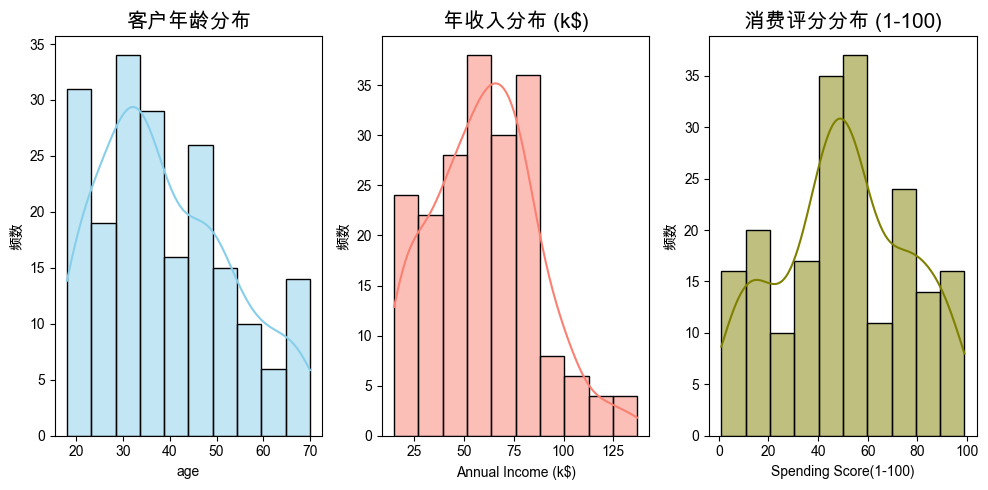

In [6]:
ig, axes = plt.subplots(1, 3, figsize=(10, 5))

sns.histplot(df['Age'], bins=10, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('客户年龄分布', fontsize=15)
axes[0].set_xlabel('age')
axes[0].set_ylabel('频数')

sns.histplot(df['Annual Income (k$)'], bins=10, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('年收入分布 (k$)', fontsize=15)
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('频数')

sns.histplot(df['Spending Score (1-100)'], bins=10, kde=True, color='olive', ax=axes[2])
axes[2].set_title('消费评分分布 (1-100)', fontsize=15)
axes[2].set_xlabel('Spending Score(1-100)')
axes[2].set_ylabel('频数')

plt.tight_layout()
plt.show()

--- 原始数据集性别分布统计 ---
Female: 112 人 (占比 56.0%)
Male: 88 人 (占比 44.0%)

数据集全局女性基准线: 56.0%


Text(0.5, 1.0, '原始数据集：性别基准分布\n(女性基准线: 56.0%)')

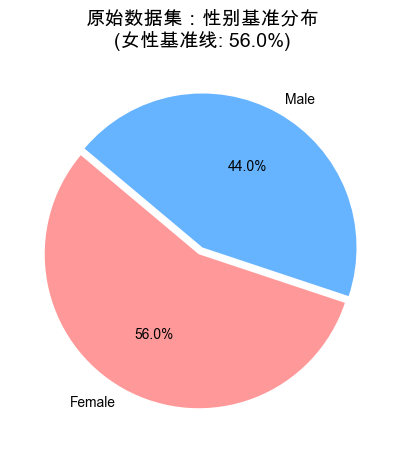

In [7]:
# 计算原始性别的绝对数量和百分比
gender_counts = df['Gender'].value_counts()
gender_pct = df['Gender'].value_counts(normalize=True) * 100

print("--- 原始数据集性别分布统计 ---")
for gender, pct in gender_pct.items():
    count = gender_counts[gender]
    print(f"{gender}: {count} 人 (占比 {pct:.1f}%)")

global_female_pct = gender_pct.get('Female', 0)
print(f"\n数据集全局女性基准线: {global_female_pct:.1f}%")

plt.figure(figsize=(10, 5))
colors = ['#ff9999','#66b3ff']  
explode = (0.05, 0)

plt.pie(gender_pct, labels=gender_pct.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, explode = explode)
plt.title(f'原始数据集：性别基准分布\n(女性基准线: {global_female_pct:.1f}%)', fontsize=14)

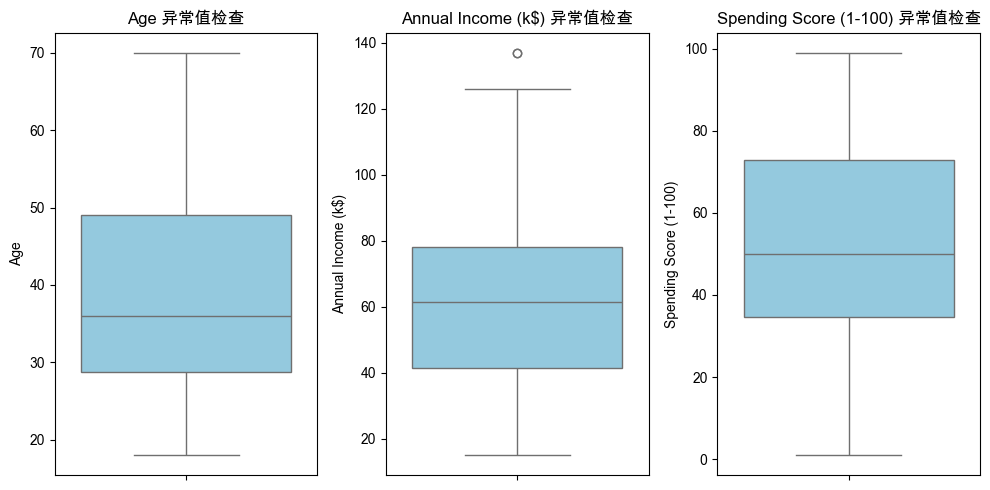

In [8]:
plt.figure(figsize=(10, 5))
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'{col} 异常值检查')
plt.tight_layout()
plt.show()

In [9]:
df_final = pd.get_dummies(df, columns=['Gender'], prefix='Gender')

X = df_final.drop(['CustomerID'], axis=1) 
print("\nOne-Hot 处理后的特征列：", X.columns.tolist())

# 消除量纲差异，确保 One-Hot 编码与数值特征在距离计算中权重平衡
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



One-Hot 处理后的特征列： ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Female', 'Gender_Male']


In [10]:
# 將縮放後的 NumPy 數組轉換為 DataFrame，並保留原始特徵列名
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# 保存為 CSV 文件（index=False 表示不保存行索引）
X_scaled_df.to_csv('X_scaled_matrix.csv', index=False, encoding='utf-8-sig')

print("✅ 特徵縮放矩陣已保存至：X_scaled_matrix.csv")

✅ 特徵縮放矩陣已保存至：X_scaled_matrix.csv


In [11]:
# 设定性别的权重因子
gender_weight = 0.2
X_scaled[:, 3:] = X_scaled[:, 3:] * gender_weight

print(f"已将性别特征权重调整为: {gender_weight}")

已将性别特征权重调整为: 0.2


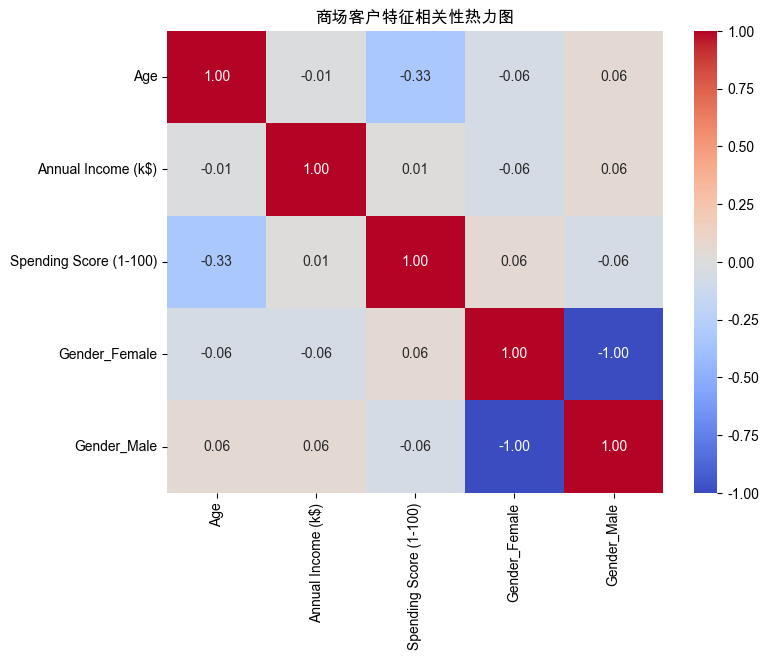

In [12]:
numerical_features = X[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Female', 'Gender_Male']]
corr_matrix = numerical_features.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('商场客户特征相关性热力图')
plt.show()

# 3. 模型构建与评估
### 3.1 最佳 K 值确定
通过 **Elbow Method（手肘法）** 观察 WCSS（簇内平方误差和）的下降斜率。实验发现 $K=5$ 为明显拐点，在模型复杂度与误差压缩之间达到了最优平衡。


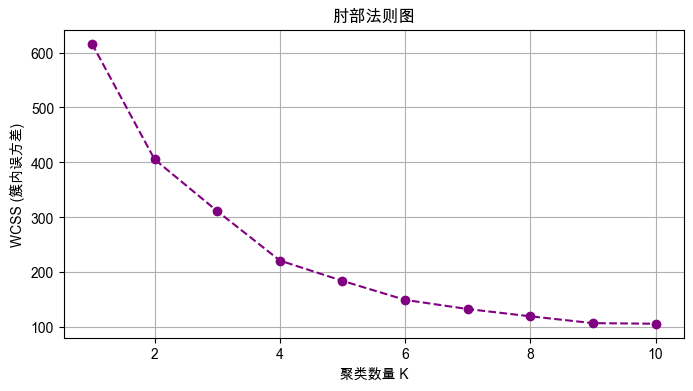

In [13]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='random', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', color='purple', linestyle='--')
plt.title('肘部法则图')
plt.xlabel('聚类数量 K')
plt.ylabel('WCSS (簇内误方差)')
plt.grid(True)
plt.show()

In [14]:
k_best = 5 
kmeans_final = KMeans(n_clusters=k_best, init='k-means++', random_state=42)
df_final['Cluster'] = kmeans_final.fit_predict(X_scaled)

In [15]:
# 直接將包含聚類標籤的完整 DataFrame 保存
df_final.to_csv('mall_customers_with_clusters.csv', index=False, encoding='utf-8-sig')

print("✅ 帶標籤的樣本數據已保存至：mall_customers_with_clusters.csv")

✅ 帶標籤的樣本數據已保存至：mall_customers_with_clusters.csv


In [16]:
wcss_imp = kmeans_final.inertia_
print(f"当前模型的 WCSS (簇内平方误差和) 为: {wcss_imp:.2f}")

当前模型的 WCSS (簇内平方误差和) 为: 184.41


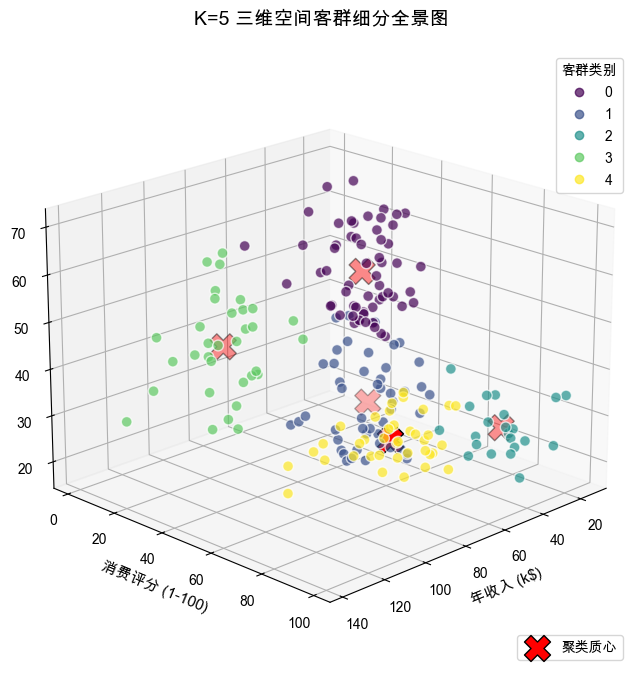

In [17]:

# 3. 质心还原 (从标准化空间回到原始物理量纲)
# 假设你的特征顺序是 [Age, Annual Income, Spending Score]
centers_orig = scaler.inverse_transform(kmeans_final.cluster_centers_)

# 4. 创建嵌入式三维交互图
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制数据点 (X:收入, Y:评分, Z:年龄)
# 注意：列名请确保与你的 df_final 一致
scatter = ax.scatter(df_final['Annual Income (k$)'], 
                     df_final['Spending Score (1-100)'], 
                     df_final['Age'], 
                     c=df_final['Cluster'], 
                     cmap='viridis', s=60, alpha=0.7, edgecolors='w')

# 绘制质心 (红色 X 标志)
# centers_orig 索引对应：0-年龄, 1-收入, 2-评分
ax.scatter(centers_orig[:, 1], centers_orig[:, 2], centers_orig[:, 0], 
           s=350, c='red', marker='X', edgecolors='black', label='聚类质心', zorder=15)

# 5. 装饰与标签 (简体中文)
ax.set_xlabel('年收入 (k$)', fontsize=11)
ax.set_ylabel('消费评分 (1-100)', fontsize=11)
ax.set_zlabel('年龄 (Age)', fontsize=11)
ax.set_title(f'K={k_best} 三维空间客群细分全景图', fontsize=14, pad=20)

# 图例设置
legend1 = ax.legend(*scatter.legend_elements(), loc="upper right", title="客群类别")
ax.add_artist(legend1)
ax.legend(loc='lower right')

# 设置初始观察视角
ax.view_init(elev=20, azim=45)

plt.show()

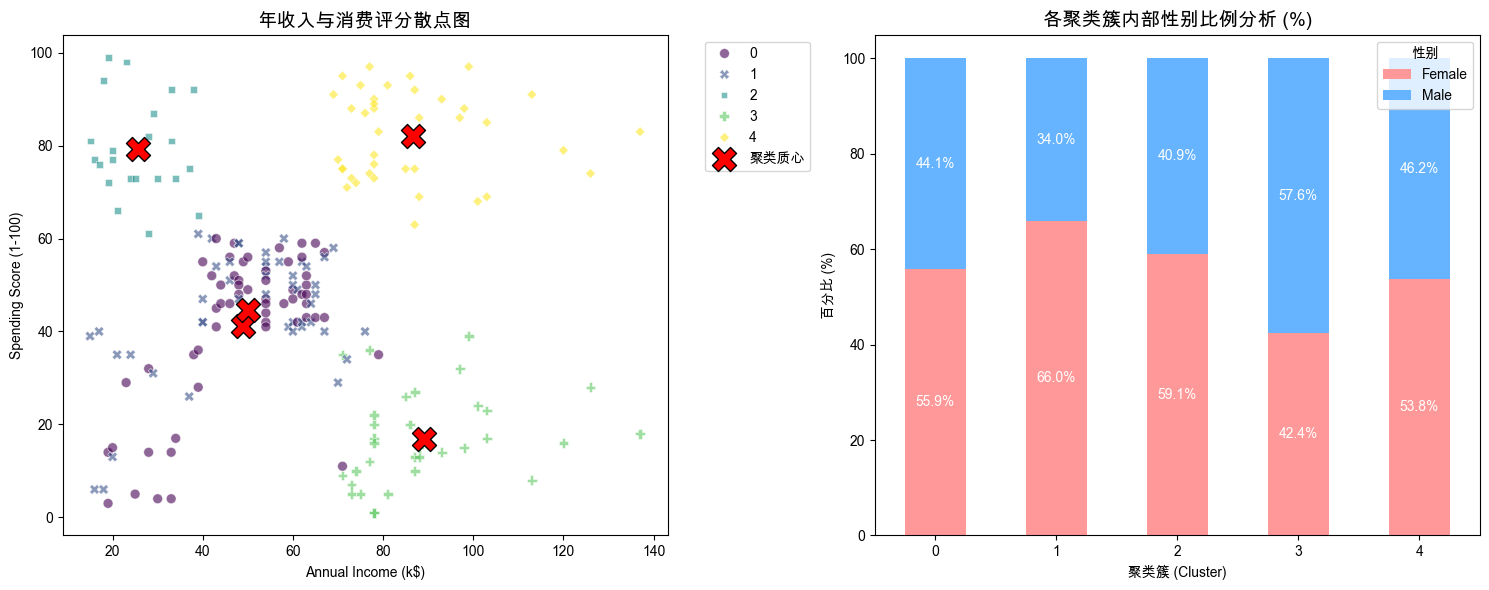

In [18]:
plt.figure(figsize=(15, 6))

if '性别' not in df_final.columns:
    df_final['性别'] = df['Gender']

# --- 子图 1：收入与评分的分布 + 标注质心 ---
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_final, x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Cluster', style='Cluster', palette='viridis', s=50, alpha=0.6)

centers_scaled = kmeans_final.cluster_centers_
centers_orig = scaler.inverse_transform(centers_scaled) 

plt.scatter(centers_orig[:, 1], centers_orig[:, 2], 
            s=300, c='red', marker='X', edgecolors='black', label='聚类质心')

plt.title('年收入与消费评分散点图', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# --- 子图 2：各簇性别占比百分比图 ---
plt.subplot(1, 2, 2)

cluster_gender_counts = df_final.groupby(['Cluster', '性别']).size().unstack(fill_value=0)
cluster_gender_pct = cluster_gender_counts.div(cluster_gender_counts.sum(axis=1), axis=0) * 100

cluster_gender_pct.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], ax=plt.gca())

for i, (idx, row) in enumerate(cluster_gender_pct.iterrows()):
    cumulative_height = 0
    for gender_col in cluster_gender_pct.columns:
        height = row[gender_col]
        if height > 0:
            plt.text(i, cumulative_height + height/2, f'{height:.1f}%', 
                     ha='center', va='center', color='white', fontweight='bold')
        cumulative_height += height

plt.title('各聚类簇内部性别比例分析 (%)', fontsize=14)
plt.xlabel('聚类簇 (Cluster)')
plt.ylabel('百分比 (%)')
plt.xticks(rotation=0)
plt.legend(title='性别', loc='upper right')

plt.tight_layout()
plt.show()

# 4. 聚类结果深度解析
通过 $K=5$ 聚类，我们成功识别出以下五类典型客群：

- **Cluster 4 精英主力军**：高收入、高消费（均龄 32.7），核心盈利贡献层。
- **Cluster 2 潜力青年派**：低收入、高消费（均龄 25.3），极具增长潜力的悦己型群体。
- **Cluster 1 都市平价族**：中等收入、女性主导（占比 66%），高频性价比受众。
- **Cluster 0 务实银发层**：中等收入、高年龄（均龄 55.6），消费理性且稳定。
- **Cluster 3 理性高净值**：极高收入、极低消费评分（男性占比 57.6%），目的性强的低频高质客群。

In [19]:
# 定义业务标签映射
cluster_labels = {
    4: "精英主力军",
    2: "潜力青年派",
    1: "都市平价族",
    0: "务实银发层",
    3: "理性高净值"
}

# 格式化输出表
analysis = df_final.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Female']].mean()
readable_analysis = analysis.copy()
readable_analysis['业务标签'] = readable_analysis.index.map(cluster_labels)
readable_analysis = readable_analysis[['业务标签', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Female']]
readable_analysis.columns = ['客群标签', '平均年龄', '年收入', '消费评分', '女性占比']

# 按消费评分降序排列
display(readable_analysis.sort_values(by='消费评分', ascending=False))

,客群标签,平均年龄,年收入,消费评分,女性占比
Cluster,,,,,
4,精英主力军,32.692308,86.538462,82.128205,0.538462
2,潜力青年派,25.272727,25.727273,79.363636,0.590909
1,都市平价族,27.957447,50.000000,44.638298,0.659574
0,务实银发层,55.610169,48.864407,41.254237,0.559322
3,理性高净值,40.727273,89.030303,16.939394,0.424242


In [20]:
# 直接將包含聚類標籤的完整 DataFrame 保存
df_final.to_csv('mall_customers_with_clusters.csv', index=False, encoding='utf-8-sig')

print("✅ 帶標籤的樣本數據已保存至：mall_customers_with_clusters.csv")

✅ 帶標籤的樣本數據已保存至：mall_customers_with_clusters.csv


### 5. 消融实验对比
本研究设置了**基线模型**（原始数据直投）与**改进模型**（标准化+加权）的对比：
- **基线模型**：受量纲主导，聚类边界呈机械的垂直分布，丧失年龄敏感性。
- **改进模型**：在多维空间协同判定，边界更具柔性，能捕捉到复杂的跨维度特征。

In [21]:
X_base = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
kmeans_base = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster_Base'] = kmeans_base.fit_predict(X_base) # 这一步会产生 Cluster_Base 列
wcss_base = kmeans_base.inertia_

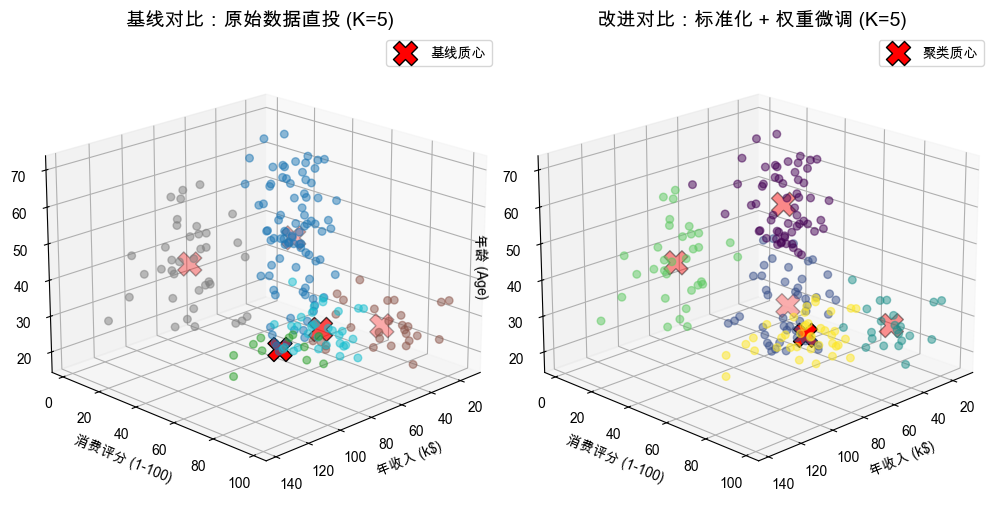

In [22]:
# 1. 创建双子图画布
fig = plt.figure(figsize=(10, 9))

# --- 左图：基线模型 (Raw Data) ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# 设定坐标轴
x_base = df['Annual Income (k$)']
y_base = df['Spending Score (1-100)']
z_base = df['Age']

# 绘制散点
scatter1 = ax1.scatter(x_base, y_base, z_base, c=df['Cluster_Base'], cmap='tab10', s=30, alpha=0.5)

# 绘制基线质心 (直接使用 groupby 计算的均值)
base_centers = df.groupby('Cluster_Base')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
ax1.scatter(base_centers['Annual Income (k$)'], base_centers['Spending Score (1-100)'], base_centers['Age'], 
            s=300, c='red', marker='X', edgecolors='black', label='基线质心', zorder=10)

# 设置标签与标题
ax1.set_xlabel('年收入 (k$)')
ax1.set_ylabel('消费评分 (1-100)')
ax1.set_zlabel('年龄 (Age)')
ax1.set_title('基线对比：原始数据直投 (K=5)', fontsize=14)
ax1.legend(loc='upper right')
ax1.view_init(elev=20, azim=45) # 保持视角一致

# --- 右图：改进模型 (Scaled + Weight) ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# 设定坐标轴 (使用 df_final)
x_imp = df_final['Annual Income (k$)']
y_imp = df_final['Spending Score (1-100)']
z_imp = df_final['Age']

# 绘制散点
scatter2 = ax2.scatter(x_imp, y_imp, z_imp, c=df_final['Cluster'], cmap='viridis', s=30, alpha=0.5)

# 绘制改进质心 (使用 inverse_transform 还原的质心)
ax2.scatter(centers_orig[:, 1], centers_orig[:, 2], centers_orig[:, 0], 
            s=300, c='red', marker='X', edgecolors='black', label='聚类质心', zorder=10)

# 设置标签与标题
ax2.set_xlabel('年收入 (k$)')
ax2.set_ylabel('消费评分 (1-100)')
ax2.set_zlabel('年龄 (Age)')
ax2.set_title('改进对比：标准化 + 权重微调 (K=5)', fontsize=14)
ax2.legend(loc='upper right')
ax2.view_init(elev=20, azim=45) # 保持视角一致

plt.tight_layout()
plt.show()

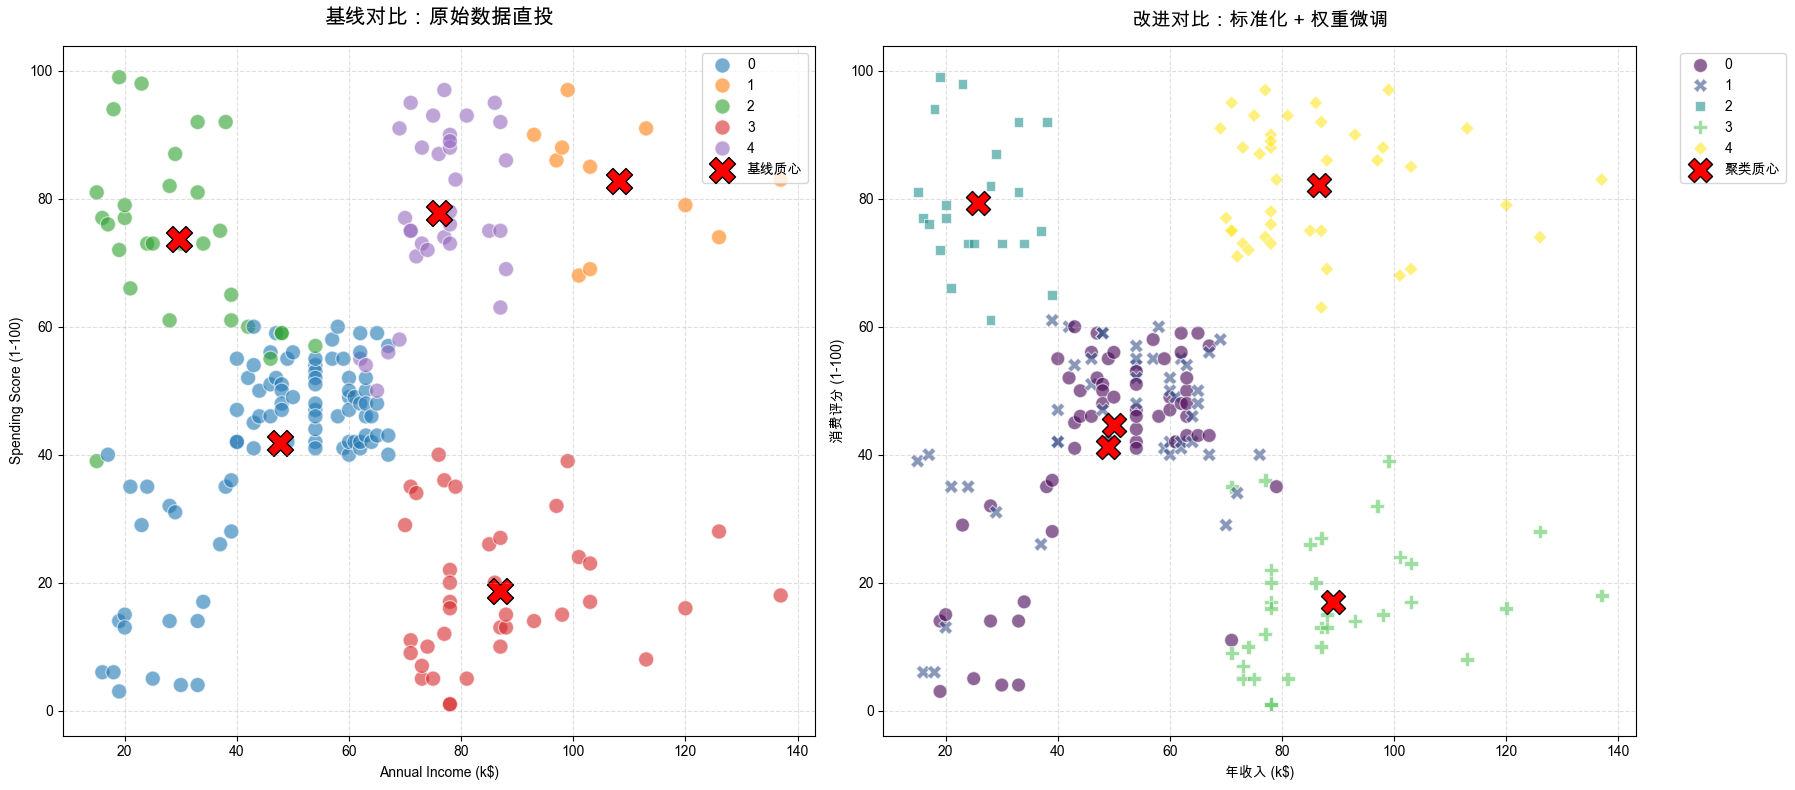

指标维度            | 基线模型 (Baseline)      | 改进模型 (Improved)     
------------------------------------------------------------
WCSS 误差值        | 97211.84             | 184.41              
特征处理            | 原始数值 (Raw)           | 标准化 + 权重微调          
分类逻辑            | 收入轴垂直分割              | 多维空间协同判定            
------------------------------------------------------------
改进模型各簇性别分布（验证 0.2 权重下的融合效果）：
性别               Female   Male
Cluster_Improved              
0                 55.9%  44.1%
1                 66.0%  34.0%
2                 59.1%  40.9%
3                 42.4%  57.6%
4                 53.8%  46.2%


In [23]:
if '性别' not in df_final.columns:
    df_final['性别'] = df['Gender']

if 'Cluster' in df_final.columns:
    df_final['Cluster_Improved'] = df_final['Cluster']

base_centers = df.groupby('Cluster_Base')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
imp_centers = df_final.groupby('Cluster_Improved')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
# --- 左图：基线模型 ---
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Cluster_Base', palette='tab10', s=120, ax=ax1, alpha=0.6, edgecolor='w')
ax1.scatter(base_centers['Annual Income (k$)'], base_centers['Spending Score (1-100)'], 
            s=350, c='red', marker='X',  edgecolors='black', label='基线质心')
ax1.set_title('基线对比：原始数据直投', fontsize=15, pad=15)
ax1.grid(True, linestyle='--', alpha = 0.4)
ax1.legend(loc='upper right')

# --- 右图：改进模型 (ax2) ---
sns.scatterplot(data=df_final, x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Cluster_Improved', style='Cluster_Improved', palette='viridis', s=100, alpha=0.6, ax=ax2)

# 还原质心
centers_scaled = kmeans_final.cluster_centers_
centers_orig = scaler.inverse_transform(centers_scaled) 

ax2.scatter(centers_orig[:, 1], centers_orig[:, 2], 
            s=300, c='red', marker='X', edgecolors='black', label='聚类质心', zorder=5)

ax2.set_title('改进对比：标准化 + 权重微调', fontsize=14, pad=15)
ax2.set_xlabel('年收入 (k$)')
ax2.set_ylabel('消费评分 (1-100)')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# 打印对比报告
print("="*60)
print(f"{'指标维度':<15} | {'基线模型 (Baseline)':<20} | {'改进模型 (Improved)':<20}")
print("-" * 60)
# 确保 wcss_base 和 wcss_imp 变量已定义
print(f"{'WCSS 误差值':<15} | {wcss_base:<20.2f} | {wcss_imp:<20.2f}")
print(f"{'特征处理':<15} | {'原始数值 (Raw)':<20} | {'标准化 + 权重微调':<20}")
print(f"{'分类逻辑':<15} | {'收入轴垂直分割':<20} | {'多维空间协同判定':<20}")

print("-" * 60)
print("改进模型各簇性别分布（验证 0.2 权重下的融合效果）：")
# 【核心修正】：使用 df_final 且确保列名正确
gender_comparison = df_final.groupby('Cluster_Improved')['性别'].value_counts(normalize=True).unstack() * 100
print(gender_comparison.round(1).astype(str) + '%')
print("="*60)